# Integração das Fontes — Transição Energética Brasileira

Este notebook integra as três fontes de dados coletadas em um
dataset único para análise e forecasting.

**Fontes:**
- SENATRAN: Frota de veículos elétricos (2021-2025)
- ANEEL: Capacidade solar instalada (2012-2026)
- ANP: Vendas de combustíveis fósseis (2015-2026)

**Output:** dataset integrado pronto para Power BI e forecasting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)

# Carregar os três datasets
df_ev = pd.read_csv('../output/senatran_serie_temporal.csv')
df_solar = pd.read_csv('../output/aneel_solar_serie_temporal.csv')
df_combustivel = pd.read_csv('../output/anp_vendas_combustiveis.csv')

# Converter datas
df_ev['data'] = pd.to_datetime(df_ev['data'])
df_solar['data'] = pd.to_datetime(df_solar['data'])
df_combustivel['data'] = pd.to_datetime(df_combustivel['data'])

print("Datasets carregados!")
print(f"  EVs: {df_ev.shape} | {df_ev['data'].min().strftime('%b/%Y')} - {df_ev['data'].max().strftime('%b/%Y')}")
print(f"  Solar: {df_solar.shape} | {df_solar['data'].min().strftime('%b/%Y')} - {df_solar['data'].max().strftime('%b/%Y')}")
print(f"  Combustível: {df_combustivel.shape} | {df_combustivel['data'].min().strftime('%b/%Y')} - {df_combustivel['data'].max().strftime('%b/%Y')}")

Datasets carregados!
  EVs: (60, 2) | Jan/2021 - Dec/2025
  Solar: (168, 6) | Jan/2012 - Mar/2026
  Combustível: (133, 5) | Jan/2015 - Jan/2026


In [2]:
# Definir período comum para análise
data_inicio = '2021-01-01'
data_fim = '2025-12-01'

# Filtrar cada dataset para o período comum
df_ev_filtrado = df_ev[
    (df_ev['data'] >= data_inicio) & 
    (df_ev['data'] <= data_fim)
][['data', 'Qtd. Veículos']].rename(columns={'Qtd. Veículos': 'frota_ev'})

df_solar_filtrado = df_solar[
    (df_solar['data'] >= data_inicio) & 
    (df_solar['data'] <= data_fim)
][['data', 'capacidade_gw_acumulada']].rename(columns={'capacidade_gw_acumulada': 'solar_gw'})

df_comb_filtrado = df_combustivel[
    (df_combustivel['data'] >= data_inicio) & 
    (df_combustivel['data'] <= data_fim)
][['data', 'volume_m3']].rename(columns={'volume_m3': 'combustivel_m3'})

# Fazer o merge das três fontes
df_integrado = df_ev_filtrado.merge(df_solar_filtrado, on='data', how='outer')
df_integrado = df_integrado.merge(df_comb_filtrado, on='data', how='outer')
df_integrado = df_integrado.sort_values('data').reset_index(drop=True)

print(f"Dataset integrado: {df_integrado.shape}")
print(f"Período: {df_integrado['data'].min().strftime('%b/%Y')} - {df_integrado['data'].max().strftime('%b/%Y')}")
print(f"\nValores nulos por coluna:")
print(df_integrado.isnull().sum())
print(f"\nAmostra:")
print(df_integrado.head(10))

Dataset integrado: (60, 4)
Período: Jan/2021 - Dec/2025

Valores nulos por coluna:
data              0
frota_ev          0
solar_gw          0
combustivel_m3    0
dtype: int64

Amostra:
        data  frota_ev  solar_gw  combustivel_m3
0 2021-01-01     55631  5.316106    1.116501e+07
1 2021-02-01     56988  5.586592    1.036482e+07
2 2021-03-01     59782  5.986792    1.151477e+07
3 2021-04-01     62343  6.290931    1.084751e+07
4 2021-05-01     65414  6.641296    1.118643e+07
5 2021-06-01     69748  6.974349    1.143457e+07
6 2021-07-01     73268  7.348024    1.247483e+07
7 2021-08-01     77629  7.759662    1.241282e+07
8 2021-09-01     80852  8.148459    1.207693e+07
9 2021-10-01     83992  8.551837    1.238220e+07


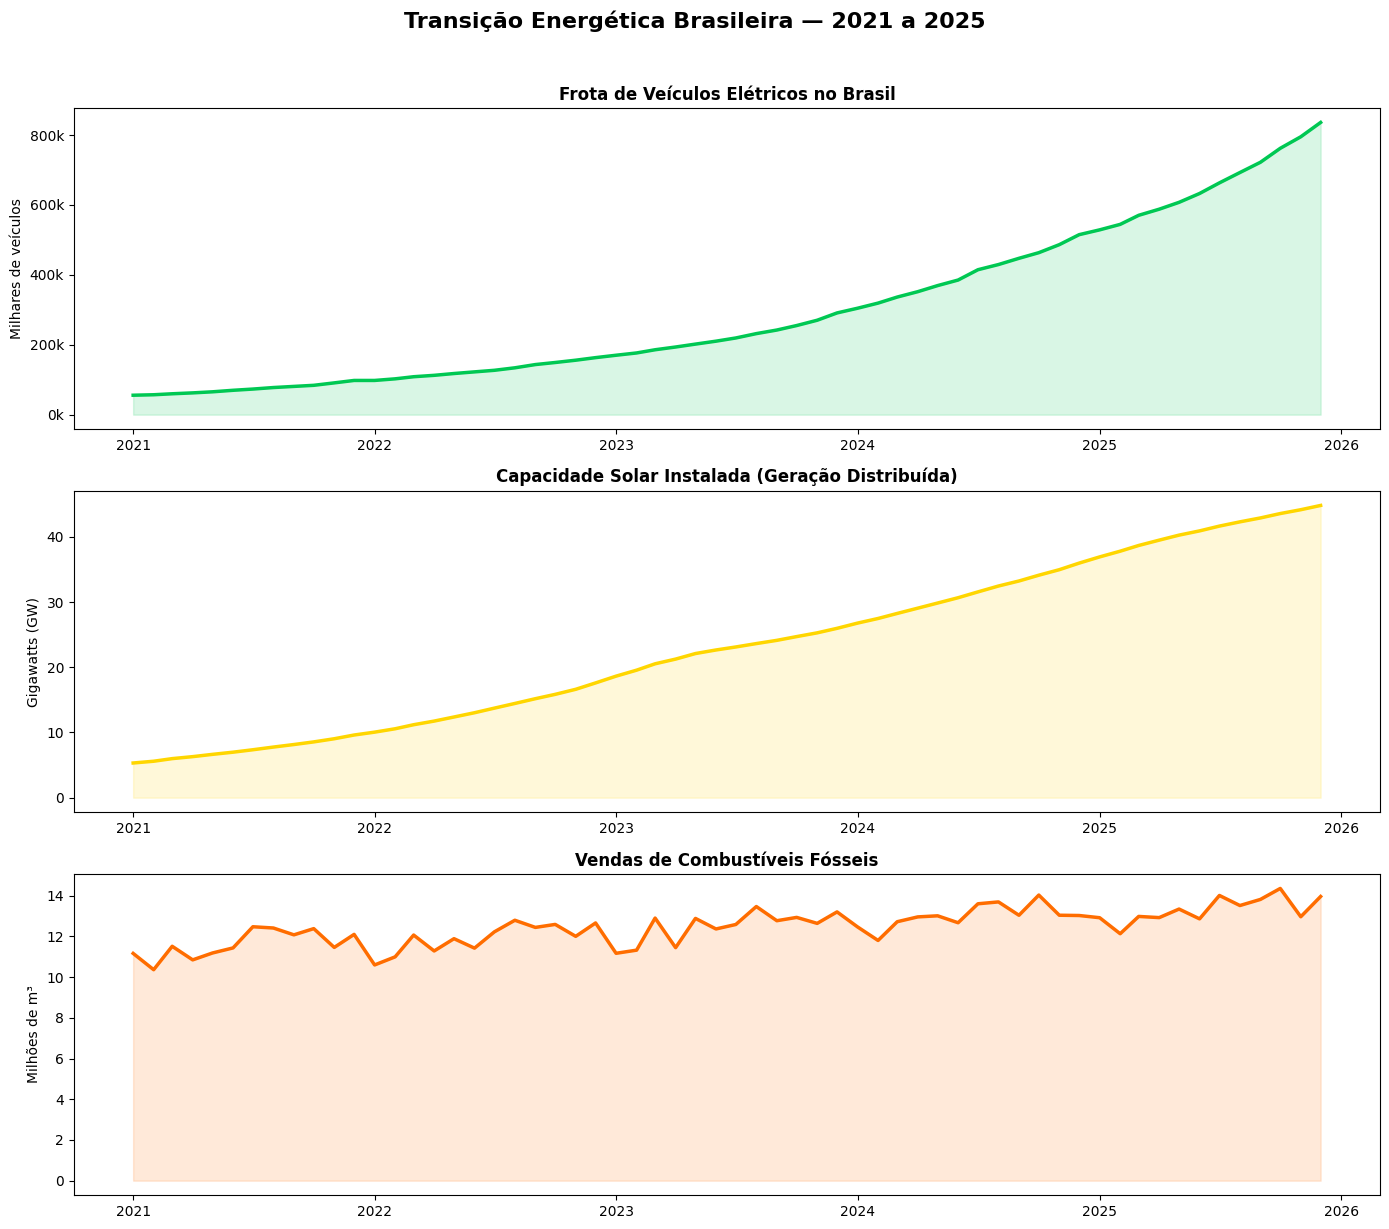

Gráfico salvo!


In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Gráfico 1 — Frota EV
ax1.plot(df_integrado['data'], df_integrado['frota_ev']/1000, 
         color='#00C853', linewidth=2.5)
ax1.fill_between(df_integrado['data'], df_integrado['frota_ev']/1000, 
                 alpha=0.15, color='#00C853')
ax1.set_title('Frota de Veículos Elétricos no Brasil', fontweight='bold', fontsize=12)
ax1.set_ylabel('Milhares de veículos')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}k'))

# Gráfico 2 — Capacidade Solar
ax2.plot(df_integrado['data'], df_integrado['solar_gw'], 
         color='#FFD600', linewidth=2.5)
ax2.fill_between(df_integrado['data'], df_integrado['solar_gw'], 
                 alpha=0.15, color='#FFD600')
ax2.set_title('Capacidade Solar Instalada (Geração Distribuída)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Gigawatts (GW)')

# Gráfico 3 — Combustíveis
ax3.plot(df_integrado['data'], df_integrado['combustivel_m3']/1e6, 
         color='#FF6D00', linewidth=2.5)
ax3.fill_between(df_integrado['data'], df_integrado['combustivel_m3']/1e6, 
                 alpha=0.15, color='#FF6D00')
ax3.set_title('Vendas de Combustíveis Fósseis', fontweight='bold', fontsize=12)
ax3.set_ylabel('Milhões de m³')

plt.suptitle('Transição Energética Brasileira — 2021 a 2025', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/transicao_energetica_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo!")

In [4]:
# Métricas principais para o dashboard
ev_inicio = df_integrado['frota_ev'].iloc[0]
ev_fim = df_integrado['frota_ev'].iloc[-1]
crescimento_ev = ((ev_fim / ev_inicio) - 1) * 100

solar_inicio = df_integrado['solar_gw'].iloc[0]
solar_fim = df_integrado['solar_gw'].iloc[-1]
crescimento_solar = ((solar_fim / solar_inicio) - 1) * 100

comb_inicio = df_integrado['combustivel_m3'].iloc[0]
comb_fim = df_integrado['combustivel_m3'].iloc[-1]
variacao_comb = ((comb_fim / comb_inicio) - 1) * 100

# Calcular demanda energética estimada dos EVs
# Um EV médio consome ~15 kWh/100km, rodando ~12.000 km/ano = 1.800 kWh/ano
consumo_kwh_por_ev = 1800
demanda_ev_gwh = (ev_fim * consumo_kwh_por_ev) / 1_000_000
capacidade_solar_gwh = solar_fim * 8760 * 0.18  # 18% fator de capacidade médio

print("=" * 50)
print("MÉTRICAS PRINCIPAIS DO PROJETO")
print("=" * 50)
print(f"\n🚗 VEÍCULOS ELÉTRICOS:")
print(f"   Jan/2021: {ev_inicio:,.0f} veículos")
print(f"   Dez/2025: {ev_fim:,.0f} veículos")
print(f"   Crescimento: +{crescimento_ev:.0f}%")

print(f"\n☀️ ENERGIA SOLAR (GD):")
print(f"   Jan/2021: {solar_inicio:.1f} GW")
print(f"   Dez/2025: {solar_fim:.1f} GW")
print(f"   Crescimento: +{crescimento_solar:.0f}%")

print(f"\n⛽ COMBUSTÍVEIS FÓSSEIS:")
print(f"   Jan/2021: {comb_inicio/1e6:.1f} milhões m³/mês")
print(f"   Dez/2025: {comb_fim/1e6:.1f} milhões m³/mês")
print(f"   Variação: {variacao_comb:+.1f}%")

print(f"\n⚡ BALANÇO ENERGÉTICO (Dez/2025):")
print(f"   Demanda estimada dos EVs: {demanda_ev_gwh:.0f} GWh/ano")
print(f"   Geração solar estimada: {capacidade_solar_gwh:.0f} GWh/ano")
print(f"   Solar cobre: {(capacidade_solar_gwh/demanda_ev_gwh)*100:.0f}x a demanda dos EVs")

MÉTRICAS PRINCIPAIS DO PROJETO

🚗 VEÍCULOS ELÉTRICOS:
   Jan/2021: 55,631 veículos
   Dez/2025: 836,151 veículos
   Crescimento: +1403%

☀️ ENERGIA SOLAR (GD):
   Jan/2021: 5.3 GW
   Dez/2025: 44.8 GW
   Crescimento: +743%

⛽ COMBUSTÍVEIS FÓSSEIS:
   Jan/2021: 11.2 milhões m³/mês
   Dez/2025: 14.0 milhões m³/mês
   Variação: +25.0%

⚡ BALANÇO ENERGÉTICO (Dez/2025):
   Demanda estimada dos EVs: 1505 GWh/ano
   Geração solar estimada: 70658 GWh/ano
   Solar cobre: 4695x a demanda dos EVs


In [5]:
# Salvar dataset integrado
df_integrado.to_csv('../output/dataset_integrado.csv', index=False)

# Salvar métricas como JSON para o dashboard
import json

metricas = {
    "ev": {
        "inicio": int(ev_inicio),
        "fim": int(ev_fim),
        "crescimento_pct": round(crescimento_ev, 1)
    },
    "solar": {
        "inicio_gw": round(solar_inicio, 1),
        "fim_gw": round(solar_fim, 1),
        "crescimento_pct": round(crescimento_solar, 1)
    },
    "combustivel": {
        "inicio_m3": round(comb_inicio, 0),
        "fim_m3": round(comb_fim, 0),
        "variacao_pct": round(variacao_comb, 1)
    },
    "balanco": {
        "demanda_ev_gwh": round(demanda_ev_gwh, 0),
        "geracao_solar_gwh": round(capacidade_solar_gwh, 0),
        "cobertura_x": round(capacidade_solar_gwh/demanda_ev_gwh, 0)
    }
}

with open('../output/metricas_dashboard.json', 'w') as f:
    json.dump(metricas, f, indent=2)

print("Arquivos salvos!")
print("\nArquivos em output/:")
import os
for f in os.listdir('../output'):
    tamanho = os.path.getsize(f'../output/{f}')
    print(f"  {f} — {tamanho/1024:.1f} KB")

Arquivos salvos!

Arquivos em output/:
  aneel_solar_serie_temporal.csv — 8.1 KB
  anp_vendas_combustiveis.csv — 5.9 KB
  dataset_integrado.csv — 3.0 KB
  metricas_dashboard.json — 0.4 KB
  senatran_serie_categoria.csv — 6.4 KB
  senatran_serie_temporal.csv — 1.1 KB
  transicao_energetica_overview.png — 143.9 KB
